# Exercise 1

In [196]:
import random 
# random.seed(42)

## 1. LCG

In [197]:
def LCG(x0, a, c, M, N):
    xmi = x0
    rando, rando_Ui = [], []
    rando.append(xmi)
    rando_Ui.append(xmi/M)
    for i in range(N):
        xi = (a*xmi+c) % M
        rando.append(xi)
        rando_Ui.append(xi/M)
        xmi = xi
    return rando, rando_Ui

### (a) - Generate 10.000 random numbers

(array([1250.,  625., 1250.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([ 0. ,  1.5,  3. ,  4.5,  6. ,  7.5,  9. , 10.5, 12. , 13.5, 15. ]),
 <BarContainer object of 10 artists>)

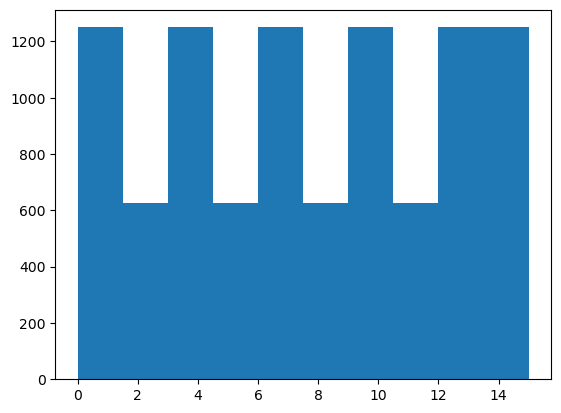

In [198]:
import matplotlib.pyplot as plt
a = 5
c = 1
M = 16
x0 = 3
N = 10000
rando, rando_Ui = LCG(x0, a, c, M, N-1)
plt.hist(rando, bins=10)

### (b) Evaluate

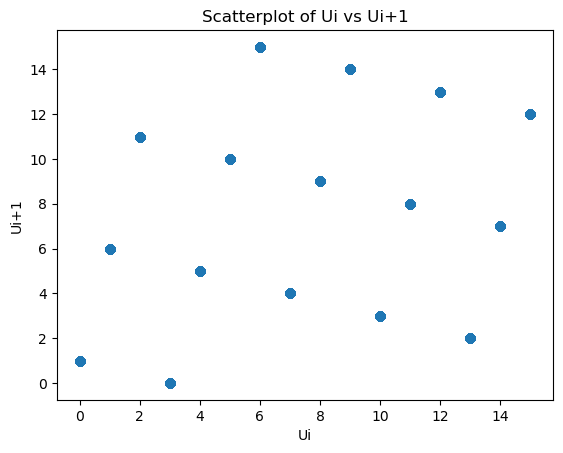

In [199]:
# Scatterplot Ui vs Ui+1
ri = rando[:-1]
ri_plus_1 = rando[1:]
plt.scatter(ri, ri_plus_1)
plt.xlabel('Ui')
plt.ylabel('Ui+1')
plt.title('Scatterplot of Ui vs Ui+1')
plt.show()

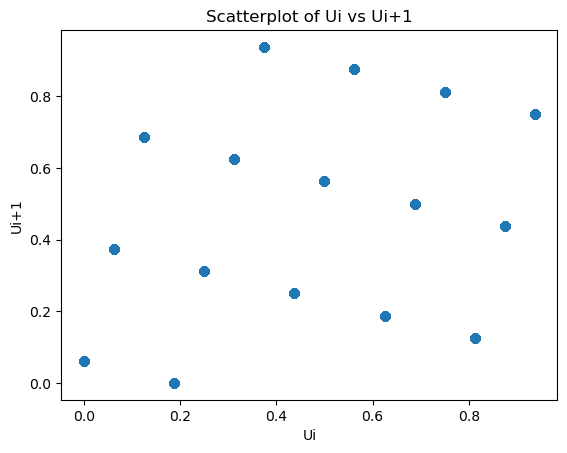

In [200]:
# Scatterplot Ui vs Ui+1
Ui = rando_Ui[:-1]
Ui_plus_1 = rando_Ui[1:]
plt.scatter(Ui, Ui_plus_1)
plt.xlabel('Ui')
plt.ylabel('Ui+1')
plt.title('Scatterplot of Ui vs Ui+1')
plt.show()

In [201]:
# Chi-squared test
def chi_squared_test(observed, expected):
    T = sum((o - e) ** 2 / e for o, e in zip(observed, expected))
    df = len(observed) - 1
    return T, df

In [202]:
import numpy as np
from scipy.stats import chi2

observed, _ = np.histogram(rando_Ui, bins=10)
expected = [len(rando_Ui) / 10] * 10
T,df = chi_squared_test(observed, expected)
print(f"Chi-squared test statistic: {T}")
print(f"Degrees of freedom: {df}")

critical_value = chi2.ppf(0.95, df)
print(f"Critical value at 95% confidence: {critical_value}")

if T > critical_value:
    print("Forkast H0")
else:
    print("Kan ikke forkaste H0")

Chi-squared test statistic: 937.5
Degrees of freedom: 9
Critical value at 95% confidence: 16.918977604620448
Forkast H0


In [225]:
# Kolmogorov-Smirnov test givet uniform
def KS_test(data, case):
    data = np.sort(data)
    n = len(data)

    Dn = 0

    for i, x in enumerate(data, start=1):
        Fn = i / n
        F = x  # For uniform distribution
        Dn = max(Dn, abs(Fn - F))
    
    if case == 'known':
        adjusted_test_stat = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))*Dn
    elif case == 'normal':
        adjusted_test_stat = (np.sqrt(n) - 0.01 + 0.85/np.sqrt(n))*Dn
    elif case == 'exp':
        adjusted_test_stat = (np.sqrt(n)+0.26+0.5/np.sqrt(n))*(Dn-0.2/n)

    print(f"Kolmogorov-Smirnov test statistic: {Dn}")
    print(f"Adjusted Kolmogorov-Smirnov test statistic: {adjusted_test_stat}")
    
    return Dn, adjusted_test_stat

In [226]:
KS_test(rando_Ui, 'known')

Kolmogorov-Smirnov test statistic: 0.0625
Adjusted Kolmogorov-Smirnov test statistic: 6.25756875


(0.0625, 6.25756875)

Da den er højere end 1.628, betyder det at selv for significance level 0.01, kan vi afvise null-hypotesen om at tallene er uniformt fordelt.

In [227]:
# run-tests

def run_wald_wolf(data):
    median = np.median(data)

    # Indel data i to sekvenser baseret på medianen
    seq = ['A' if x > median else 'B' for x in data]

    count_below = seq.count('A')
    count_above = seq.count('B')

    # Tæl runs
    T = 1
    for i in range(1, len(seq)):
        if seq[i] != seq[i-1]:
            T += 1
    
    # Udregn forventning og varians
    expectation = 2*(count_above * count_below) / (count_above + count_below)
    variance = (2*count_above * count_below * (2*count_above*count_below - count_above - count_below)) / ((count_above + count_below)**2 * (count_above + count_below - 1))

    z = (T - expectation) / np.sqrt(variance)
    print(f"Number of runs: {T}")
    print(f"Z-score: {z}")

    return T,(T-expectation) / np.sqrt(variance)


In [228]:
run_wald_wolf(rando_Ui)

Number of runs: 3750
Z-score: -25.001250218789068


(3750, -25.001250218789068)

In [229]:
def run_knuth(data):
    T= 1
    run_length = []
    start = 1
    for i in range(1,len(data)):
        if data[i] < data[i-1]:
            T += 1
            run_length.append(start)
            start = 1
        else:
            start += 1
    run_length.append(start)

    R = np.zeros(6)

    for r in run_length:
        if r >= 6:
            R[5] += 1
        else:
            R[r - 1] += 1

    n = len(data)

    B = np.array([
        1/6,
        5/24,
        11/120,
        19/720,
        29/5040,
        1/840
    ])

    A = np.array([
        [4529.4, 9044.9, 13568, 18091, 22615, 27892],
        [9044.9, 18097, 27139, 36187, 45234, 55789],
        [13568, 27139, 40721, 54281, 67852, 83685],
        [18091, 36187, 54281, 72414, 90470, 111580],
        [22615, 45234, 67852, 90470, 113262, 139476],
        [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    D = R - n * B

    Z = (1 / (n - 6)) * (D.T @ A @ D)

    print(f"Number of runs: {T}")
    print(f"Z-score: {Z}")

    return T, Z

In [230]:
run_knuth(rando_Ui)

Number of runs: 4375
Z-score: 1118.826845364202


(4375, 1118.826845364202)

In [231]:
chi2.ppf(0.99, 6)
print(f"Critical value at 99% confidence: {chi2.ppf(0.99, 6)}")

Critical value at 99% confidence: 16.811893829770927


In [232]:
def run_up_down(data):
    signs = []

    for i in range(1, len(data)):
        if data[i] < data[i-1]:
            signs.append('<')
        else:
            signs.append('>')

    run_length = []
    current = 1
    for i in range(1, len(signs)):
        if signs[i] == signs[i-1]:
            current += 1
        else:
            run_length.append(current)
            current = 1

    run_length.append(current)

    runs = len(run_length)
    n = len(data)
    expected_runs = (2*n - 1) / 3
    variance_runs = (16*n - 29) / 90

    Z = (runs - expected_runs) / (np.sqrt(variance_runs))

    print(f"Number of runs: {runs}")
    print(f"Z-score: {Z}")

    return runs, Z

In [233]:
run_up_down(rando_Ui)

Number of runs: 6250
Z-score: -9.875106965999812


(6250, -9.875106965999812)

In [212]:
def correlation_test(data, lag):
    n = len(data)
    h = lag

    sum = 0
    for i in range(1, n-h):
        sum += data[i]*data[i+h]

    Ch_calculated = 1/(n-h) * sum
    
    expectation = 1/4
    variance = 7/(144*n)

    z = (Ch_calculated-expectation)/np.sqrt(variance)

    return Ch_calculated, z


In [213]:
for h in [1,2,5,10]:
    print(correlation_test(rando_Ui, h))

(0.24220000125012503, -3.537746900362949)
(0.21683321039207842, -15.043041786679192)
(0.22657344297148577, -10.625287538043588)
(0.21675503628628628, -15.078498228317624)


### (c) Repeat

## 2. SAG

In [214]:
np.random.seed(42)
data = np.random.rand(10000)

(array([1250.,  625., 1250.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([ 0. ,  1.5,  3. ,  4.5,  6. ,  7.5,  9. , 10.5, 12. , 13.5, 15. ]),
 <BarContainer object of 10 artists>)

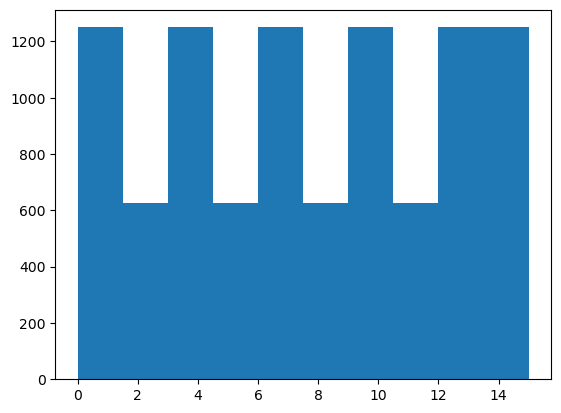

In [215]:
plt.hist(rando, bins=10)

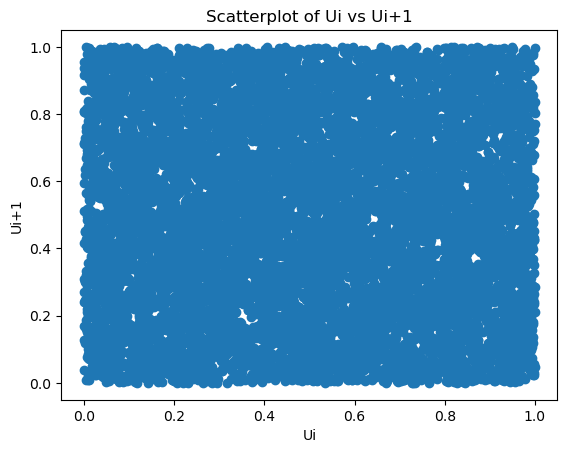

In [224]:
# Scatterplot Ui vs Ui+1
Ui = data[:-1]
Ui_plus_1 = data[1:]
plt.scatter(Ui, Ui_plus_1)
plt.xlabel('Ui')
plt.ylabel('Ui+1')
plt.title('Scatterplot of Ui vs Ui+1')
plt.show()

In [217]:
import numpy as np
from scipy.stats import chi2

observed, _ = np.histogram(data, bins=10)
expected = [len(data) / 10] * 10
T,df = chi_squared_test(observed, expected)
print(f"Chi-squared test statistic: {T}")
print(f"Degrees of freedom: {df}")

critical_value = chi2.ppf(0.95, df)
print(f"Critical value at 95% confidence: {critical_value}")

if T > critical_value:
    print("Forkast H0")
else:
    print("Kan ikke forkaste H0")

Chi-squared test statistic: 10.1
Degrees of freedom: 9
Critical value at 95% confidence: 16.918977604620448
Kan ikke forkaste H0


In [218]:
KS_test(data, 'known')

(0.012528538330716321, 1.254371039063482)

In [219]:
run_wald_wolf(data)

(5063, 1.260063011026969)

In [220]:
run_knuth(data)

(4998, 2.7793400353636732)

In [221]:
chi2.ppf(0.95, 6)

12.591587243743977

In [222]:
run_up_down(data)

(6672, 0.13440898192314327)

In [223]:
for h in [1,2,5,10]:
    print(correlation_test(data, h))

(0.24314470642656016, -3.109268907370476)
(0.24372227155468915, -2.8473099882323427)
(0.24371369469068113, -2.851200088094176)
(0.24412340834188204, -2.665371442981172)


## 3. Discuss

In [ ]:
p = 0.1
X = np.random.geometric(p, size=10000)
plt.hist(X, bins=10)
# Scatterplot Ui vs Ui+1
Ui = X[:-1]
Ui_plus_1 = X[1:]
plt.scatter(Ui, Ui_plus_1)
plt.xlabel('Ui')
plt.ylabel('Ui+1')
plt.title('Scatterplot of Ui vs Ui+1')
plt.show()
observed, _ = np.histogram(X, bins=10)
expected = [len(X) / 10] * 10
RandomnessTests.chi_squared_test(observed, expected)
RandomnessTests.KS_test(X, 'known')
RandomnessTests.run_wald_wolf(X)
RandomnessTests.run_knuth(X)
RandomnessTests.run_up_down(X)
for h in [1,2,5,10]:
    print(RandomnessTests.correlation_test(X, h))